<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto de árbol de decisión**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto prediciendo la diabetes  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Prediciendo la diabetes**

El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **diabetes.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/diabetes.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# IMPORTACIONES LIBRERIAS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/diabetes.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
695,7,142,90,24,480,30.4,0.128,43,1
343,5,122,86,0,0,34.7,0.290,33,0
270,10,101,86,37,0,45.6,1.136,38,1
185,7,194,68,28,0,35.9,0.745,41,1
613,6,105,80,28,0,32.5,0.878,26,0
764,2,122,70,27,0,36.8,0.340,27,0
166,3,148,66,25,0,32.5,0.256,22,0
282,7,133,88,15,155,32.4,0.262,37,0
52,5,88,66,21,23,24.4,0.342,30,0
540,8,100,74,40,215,39.4,0.661,43,1


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

A continuación se detallan las variables incluidas en el dataset:

### 📊 Diccionario de Datos

| Variable | Descripción | Tipo |
|----------|------------|------|
| Pregnancies | Número de embarazos del paciente | Numérico |
| Glucose | Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa | Numérico |
| BloodPressure | Presión arterial diastólica (mm Hg) | Numérico |
| SkinThickness | Grosor del pliegue cutáneo del tríceps (mm) | Numérico |
| Insulin | Insulina sérica a las 2 horas (mu U/ml) | Numérico |
| BMI | Índice de masa corporal | Numérico |
| DiabetesPedigreeFunction | Función de pedigrí de diabetes | Numérico |
| Age | Edad del paciente | Numérico |
| Outcome | Variable objetivo (0 = negativo en diabetes, 1 = positivo) | Numérico |

Este diccionario de datos será clave para interpretar correctamente las relaciones entre variables durante el análisis exploratorio (EDA).

</div>

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**
------
El dataset muestra un conjunto de variables asociadas a clientes del banco, que se pueden clasificar de la siguiente manera:

- Personal: `age`, `job`, `marital`, `education`
- Crediticia: `default`, `housing`, `loan`
- Datos de la llamada: `contact`, `month`, `day_of_week`, `duration`
- Datos de campañas: `campaign`, `pdays`, `previous`, `poutcome`
- Datos macroeconómicos: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

No se observa a simple vista una columna que identifique unívocamente cada registro. Además, la variable `campaign` indica el número de contactos realizados durante la campaña actual a un cliente en el momento del registro. Esto sugiere que cada fila representa un evento de contacto, y que un mismo cliente podría aparecer en múltiples registros con valores crecientes en esta variable.

No obstante, la ausencia de un identificador único de cliente impide confirmar esta relación de forma directa. Asimismo, no existe una variable que identifique explícitamente las distintas campañas, aunque variables como `previous`, `pdays` y `poutcome` indican la existencia de interacciones previas en campañas anteriores.

💭 Hipótesis:
Cada fila podría representar un contacto (llamada) realizado a un cliente en un momento determinado. Esta hipótesis deberá ser validada posteriormente mediante el análisis de duplicados y la comprensión de las variables relacionadas con las campañas.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Inspección inicial del dataset**

</div>

In [3]:
# Obtener las dimensiones
df.shape

(768, 9)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Valores nulos
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**
-----
El dataset contiene un total de 41.188 observaciones y 21 variables (incluyendo la target).

No se detectan valores nulos en ninguna de las variables, por lo que no es necesario realizar ningún tratamiento adicional en esta fase.

Se observa la presencia de variables tanto numéricas como categóricas, lo que implicará la necesidad de aplicar técnicas de codificación para las variables categóricas en fases posteriores del análisis.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Inspección valores unicos y duplicados**

</div>

In [6]:
# Veamos cuantos valores unicos y no unicos (repetidos) hay en cada variable

df_uniques = df.nunique()
df_repeated = len(df) - df_uniques

resumen = pd.DataFrame({
    'valores_unicos': df_uniques,
    'valores_repetidos': df_repeated
})

resumen

,valores_unicos,valores_repetidos
Pregnancies,17,751
Glucose,136,632
BloodPressure,47,721
SkinThickness,51,717
Insulin,186,582
BMI,248,520
DiabetesPedigreeFunction,517,251
Age,52,716
Outcome,2,766


In [8]:
# Veamos si existe duplicado de filas (filas completamente identicas en todas su variables en el dataset)
df.duplicated().sum()

np.int64(0)

In [9]:
# Veamos si hay columnas duplicadas entre sí
df.T.duplicated()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

------

Las 10 variables categóricas (excluyendo la target) presentan un número reducido de valores únicos, siendo la variable `job` la de mayor cardinalidad con 12 valores. Esto facilita su tratamiento mediante técnicas de codificación en fases posteriores.

Por otro lado, variables como `job`, `marital`, `education`, `default`, `housing` y `loan` incluyen la categoría `unknown`, si el procentajes de valores `unknown` es muy alto quizas deban ser tratados adecuadamente más adelante.

Se identifican 12 filas completamente duplicadas en el dataset. Dado que presentan exactamente los mismos valores en todas sus variables, es probable que se trate de registros redundantes. **No obstante, su tratamiento se abordará en la fase de ingenieria de caracteristicas para mantener la coherencia del proceso de análisis.**

Ademas, se ha comprobado si existe duplicado en las columnas y el resultado es negativo, con lo qu ecada carateristica representa informacion diferente.

Todo lo observado hasta ahora no permite confirmar ni descartar la hipótesis de que cada fila representa un contacto (llamada), por lo que será necesario profundizar en el análisis para validar esta suposición a continuación:

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.3: Análisis estadístico descriptivo**

</div>

In [11]:
# Se calculan estadísticas descriptivo para las variables numericas comprender su distribución, rango de valores y posibles valores outliers
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**:

-----

- **age** presenta una distribución aproximadamente simétrica, ya que la media (40.02) y la mediana (38) están relativamente próximas. No se observan indicios claros de valores atípicos relevantes.

- **duration** muestra una distribución claramente asimétrica a la derecha. La desviación estándar (259.27) es similar e incluso superior a la media (258.28), y el valor máximo (4918) está muy alejado de la mediana (180), lo que indica la presencia de valores extremos.

- **campaign** indica el número de contactos realizados en la campaña actual. Presenta un comportamiento similar al de `duration`, con una distribución sesgada a la derecha. Aunque la mayoría de los valores se concentran en valores bajos (mediana = 2), existen valores máximos elevados (56) que incrementan significativamente la desviación estándar, lo que sugiere la presencia de outliers.

- **pdays** requiere una interpretación más detallada. Esta variable representa el número de días transcurridos desde el último contacto en una campaña anterior. El valor 999 no corresponde a un número real de días, sino que indica que el cliente no fue contactado previamente. Esto explica que tanto el percentil 25, mediana y percentil 75 sean 999, mostrando que la mayoría de los clientes no tuvieron contacto previo.

- **previous** indica el número de contactos realizados en campañas anteriores. Se observa que la gran mayoría de los valores son 0 (mediana = 0, media = 0.17), lo que sugiere que la mayoría de los clientes no habían sido contactados anteriormente. Los valores más altos como el 7 puede que represente casos poco frecuentes.

- Las variables **emp.var.rate**, **cons.price.idx**, **cons.conf.idx**, **euribor3m** y **nr.employed** representan el contexto económico en el momento del contacto. Aunque en esta fase no se profundiza en su análisis, podrían resultar relevantes en etapas posteriores del modelado.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables numericas)**

</div>

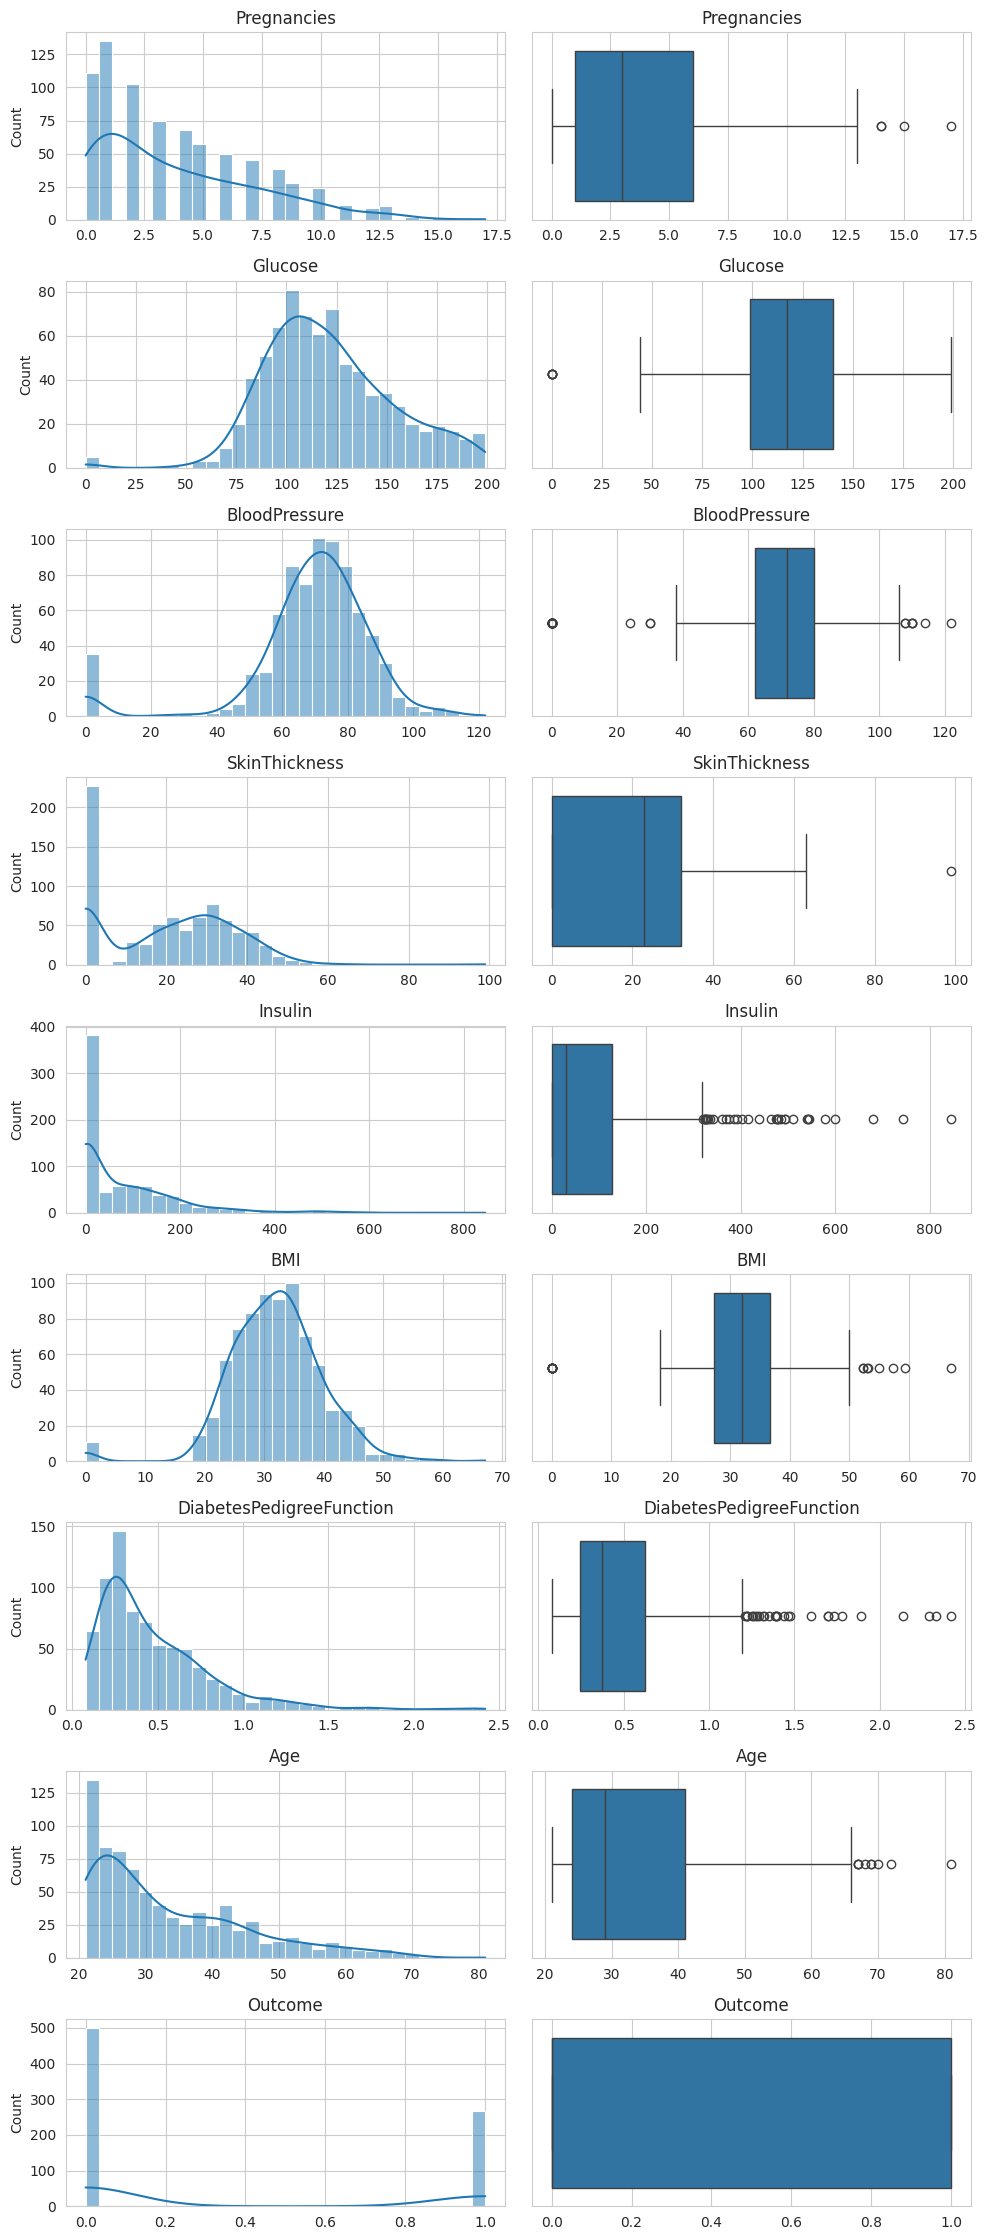

In [ ]:
# Seleccionamos variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Estilo limpio
sns.set_style("whitegrid")

# Ajustamos tamaño (más compacto que el tuyo)
fig, axes = plt.subplots(len(num_vars), 2, figsize=(10, 2.5*len(num_vars)))

for i, col in enumerate(num_vars):

    # Histograma
    sns.histplot(df[col], bins=30, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'{col}')
    axes[i, 0].set_xlabel('')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación (refinada tras graficos)**:

- **age** Aunque inicialmente la variable `age` parecía presentar una distribución aproximadamente simétrica al comparar media y mediana, el análisis gráfico revela una ligera asimetría hacia la derecha.

    Se observa una mayor concentración de valores entre los 30 y 50 años, con una cola que se extiende hacia edades más avanzadas. El boxplot confirma la presencia de valores atípicos en edades altas.

- **campaign y previous** Aunque las variables `campaign` y `previous` representan el número de contactos realizados, muestran distribuciones muy diferentes.

    La variable `previous` presenta una fuerte concentración en el valor 0, lo que indica que la mayoría de los clientes no habían sido contactados en campañas anteriores, comportándose como una variable prácticamente discreta.

    Por el contrario, `campaign` muestra una distribución más dispersa y asimétrica, con presencia de valores elevados, lo que sugiere que durante la campaña actual algunos clientes han sido contactados múltiples veces.

    Esto refleja diferencias en el comportamiento histórico frente al actual de las campañas de marketing.

- **duration** La variable `duration` presenta una distribución fuertemente asimétrica a la derecha, con una alta concentración de valores bajos y una cola larga que incluye valores extremos. Esto indica que la mayoría de las llamadas son de corta duración, aunque existen algunos casos con duraciones significativamente elevadas.

- **pdays** la variable `pdays` muestra una distribución altamente concentrada en el valor 999, lo que sugiere que la mayoría de los clientes no habían sido contactados previamente. Este comportamiento indica que la variable contiene un valor codificado que representa la ausencia de contacto previo, lo que deberá tenerse en cuenta en fases posteriores del análisis.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables categóricas)**

</div>

In [ ]:
# Seleccionamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Estilo limpio
sns.set_style("whitegrid")

# Tamaño dinámico (más alto para que se vea mejor)
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(10, 5 * len(cat_vars)))

# Si solo hay una variable, axes no es lista → lo convertimos
if len(cat_vars) == 1:
    axes = [axes]

for i, col in enumerate(cat_vars):

    # Countplot ordenado por frecuencia
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)

    # Añadir porcentajes encima de cada barra
    total = len(df)
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].text(
            p.get_x() + p.get_width() / 2,
            height,
            f'{height/total:.1%}',
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Estética
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**:

Las variables categóricas presentan una distribución desigual entre sus categorías. En el caso de la variable `job`, se observa que las categorías `admin.` (~25%) y `blue-collar` (~22%) concentran la mayor proporción de registros, seguidas por `technician` (~16%).

El resto de categorías presentan una frecuencia significativamente menor, muchas de ellas por debajo del 5%, lo que indica la existencia de categorías minoritarias. Además, la categoría `unknown` representa un porcentaje muy reducido (~1%), lo que sugiere que su impacto en el análisis podría ser limitado.

La variable objetivo (y) se incluye dentro del análisis univariable de variables categóricas, observandose un fuerte desbalance entre clases, con una clara predominancia de la categoría "no" frente a "yes", lo cual podría afectar la capacidad del modelo para predecir correctamente la clase minoritaria.

Para facilitar la interpretación, se ha optado por representar las distribuciones en términos porcentuales en lugar de frecuencias absolutas.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.5: Analisis bivariante (categoricas vs target)**

</div>

In [ ]:
# ============================================
# Gráficos categóricos vs target (y)
# con porcentaje de 'yes' y 'no'
# ============================================

# Seleccionamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Quitamos la target
cat_vars = [col for col in cat_vars if col != 'y']

# Estilo visual
sns.set_style("whitegrid")

# Creamos figura (más alto que ancho, como te gusta)
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(8, 5 * len(cat_vars)))

# Si solo hay una variable
if len(cat_vars) == 1:
    axes = [axes]

# Loop por cada variable categórica
for i, col in enumerate(cat_vars):

    order = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        x=col,
        hue='y',
        order=order,
        ax=axes[i]
    )

    # Tabla de proporciones
    prop = pd.crosstab(df[col], df['y'], normalize='index').reindex(order)

    # Añadir porcentajes
    for j, category in enumerate(order):

        count_no = df[(df[col] == category) & (df['y'] == 'no')].shape[0]
        count_yes = df[(df[col] == category) & (df['y'] == 'yes')].shape[0]

        pct_no = prop.loc[category, 'no'] if 'no' in prop.columns else 0
        pct_yes = prop.loc[category, 'yes'] if 'yes' in prop.columns else 0

        # Texto NO (barra azul)
        ax.text(
            j - 0.2,
            count_no + max(count_no * 0.02, 5),
            f'{pct_no:.1%}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

        # Texto YES (barra naranja)
        ax.text(
            j + 0.2,
            count_yes + max(count_yes * 0.02, 5),
            f'{pct_yes:.1%}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='darkorange'
        )

    # Estética
    ax.set_title(f'{col} vs target', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.2)
    ax.legend(title='y')

plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación (Análisis bivariante: variables categóricas vs target):**

El análisis bivariante de las variables categóricas frente a la variable objetivo (y) permite identificar patrones de comportamiento en la contratación del depósito:

- Variables temporales como `month` y `day_of_week` no muestran un impacto significativo en la decisión de contratación, observándose distribuciones bastante homogéneas. Aunque el mes de mayo presenta un mayor volumen de contrataciones, esto parece estar influenciado por un mayor número de contactos y no necesariamente por una mayor propensión.

- En cuanto al canal de contacto (`contact`), se observa un mayor número de contrataciones en clientes contactados vía móvil. No obstante, esta diferencia podría estar condicionada por la mayor frecuencia de uso de este canal frente al teléfono fijo, más que por una mayor efectividad del mismo.

- Respecto a variables financieras, los clientes que no presentan créditos (`default = no`, `loan = no`) muestran una mayor proporción de contratación, lo que sugiere que una menor carga financiera podría estar asociada a una mayor capacidad o disposición para invertir en depósitos a largo plazo.

- En el caso de `housing`, se aprecia una ligera mayor propensión a la contratación en clientes con préstamo hipotecario, aunque la diferencia no es lo suficientemente marcada como para considerarla determinante.

- La variable `poutcome` resulta especialmente relevante: los clientes que tuvieron un resultado previo exitoso (`success`) presentan una proporción significativamente mayor de contratación, lo que indica una fuerte relación entre experiencias positivas previas y la probabilidad de conversión.

En conclusión, las variables `default`, `housing`, `loan` y `poutcome` muestran una mayor influencia sobre la variable objetivo que las variables `month`, `day_of_week` y `contact`. Por su parte, variables como `job`, `marital` y `education` no presentan diferencias suficientemente marcadas en la proporción de contratación entre sus categorías, lo que sugiere un impacto limitado en la variable objetivo en esta fase del análisis.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.6: Analisis bivariante (numéricas vs target)**

</div>

In [ ]:
# ============================================
# Análisis numérico vs target (visual + tabla)
# ============================================

# Seleccionamos variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns
num_vars = [col for col in num_vars if col != 'y']

sns.set_style("whitegrid")

# ============================================
# 1. GRÁFICOS (histograma + boxplot)
# ============================================

fig, axes = plt.subplots(len(num_vars), 2, figsize=(12, 4 * len(num_vars)))

# Si solo hay una variable
if len(num_vars) == 1:
    axes = [axes]

for i, col in enumerate(num_vars):

    # HISTOGRAMA
    sns.histplot(data=df, x=col, hue='y', bins=30, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f'Distribución de {col}')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frecuencia')
    axes[i][0].grid(True, alpha=0.2)

    # BOXPLOT
    sns.boxplot(data=df, x='y', y=col, ax=axes[i][1])
    axes[i][1].set_title(f'Boxplot de {col}')
    axes[i][1].set_xlabel('')
    axes[i][1].set_ylabel(col)
    axes[i][1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================
# 2. TABLA (media por grupo)
# ============================================

tabla_medias = df.groupby('y')[num_vars].mean().T

print("\n📊 Media de variables numéricas por grupo (y):\n")
display(tabla_medias)

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación (Análisis bivariante: variables numéricas vs target):**

El análisis de las variables numéricas en relación con la variable objetivo (`y`) permite identificar qué variables presentan mayor capacidad discriminativa entre clientes que contratan y no contratan el depósito.

La variable **duration** destaca claramente como la más influyente, observándose una diferencia significativa en la distribución entre ambos grupos: los clientes que contratan (`yes`) presentan duraciones de llamada considerablemente mayores, con una mediana claramente desplazada respecto a los que no contratan, lo que sugiere una fuerte relación entre la duración del contacto y la probabilidad de contratación.

En cuanto a **campaign**, se observa que los clientes que no contratan tienden a presentar un mayor número de contactos dentro de la campaña, mientras que aquellos que contratan suelen concentrarse en valores más bajos, lo que podría indicar una menor necesidad de insistencia en clientes con mayor predisposición.

La variable **previous** muestra que los clientes que contratan presentan, en general, un mayor número de contactos en campañas anteriores, lo que sugiere que la recurrencia en el contacto puede estar asociada a una mayor probabilidad de conversión.

Respecto a **pdays**, se observa una fuerte concentración en el valor 999 para ambos grupos, lo que indica que la mayoría de los clientes no habían sido contactados previamente. Esta variable requiere un tratamiento específico, ya que dicho valor parece representar una categoría implícita más que un valor numérico real.

En relación con **age**, no se aprecian diferencias suficientemente marcadas entre los grupos como para considerarla una variable determinante en la contratación.

Por último, las variables económicas (**emp.var.rate**, **cons.price.idx**, **cons.conf.idx**, **euribor3m**, **nr.employed**) muestran ligeras diferencias entre los grupos, especialmente en **euribor3m** y **nr.employed**, donde los clientes que contratan tienden a concentrarse en valores más bajos, lo que podría reflejar una mayor propensión a contratar depósitos en determinados contextos económicos.

En conjunto, las variables **duration**, **campaign**, **previous** y, en menor medida, **euribor3m** y **nr.employed**, parecen aportar mayor información para explicar la variable objetivo, mientras que variables como **age** presentan un impacto más limitado en esta fase del análisis.

</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final**

Tras el análisis exploratorio se puede concluir lo siguiente:

- Las variables que mas destacan como influyentes con la variable objetivo (y) son: `poutcome`, `duration`, `previous`, `campaign`, así como las variables financieras `default`, `housing` y `loan`. Por el contrario, variables como `job`, `marital`, `education`, `month`, `day_of_week` y `contact` muestran un impacto más limitado en la contratación.

- Las variables `default`, `housing` y `loan` parecen recoger información relacionada con la existencia de crédito o deuda activa del cliente. Dado que `housing` y `loan` representan tipos específicos de préstamo, mientras que `default` se define en la documentación como una variable más general (“¿Tiene crédito actualmente?”), podría existir cierto solapamiento entre ellas. No obstante, se pospondra a la fase de ingeniería de características el analisis detallado para determinar el grado real de redundancia entre las mismas. 

- La variable `contact` no parece aportar valor explicativo relevante sobre la variable objetivo, ya que las diferencias observadas podrían estar influenciadas por factores externos. Por ello, se considera candidata a eliminación en la fase de ingeniería de características.

- Se detectan 12 registros completamente duplicados en el dataset que podrían ser candidatos a eliminar en la siguiente fase de ingeniería de características.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Construye un modelo de regresión logística**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.1: Ingeniería de características**

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción sobre los 12 registros duplicados:**

Durante el EDA se detectarón 12 registros completamente duplicados en el dataset. Dado que representan una proporción mínima sobre el total de observaciones y no se dispone de un identificador único que permita confirmar si corresponden a registros redundantes o a contactos independientes con características coincidentes, no se procederá a su eliminación.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción la variable `contact`:**

La variable `contact` indica el canal utilizado para contactar al cliente (teléfono fijo o móvil). Durante el EDA no se observa una relación clara y directa con la variable objetivo, ya que las diferencias en la proporción de contratación podrían estar influenciadas por factores externos, como el mayor uso actual del teléfono móvil frente al fijo, y no necesariamente por una mayor efectividad del canal en sí.

Por ello, se considera que esta variable **no aporta información relevante para el modelo** y se procede a elimanrla.

</div>

In [ ]:
# Se elimina la variable ´contact´
fd = df.drop(columns=['contact'])

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción sobre variables `default`, `housing` y `loan`:**

Se ha analizado la posible relación entre las variables `default`, `housing` y `loan` con el objetivo de identificar si existe redundancia entre ellas.

Los resultados muestran que `default` no actúa como una variable general que agrupe a `housing` y `loan`, ya que existen numerosos casos en los que los clientes presentan préstamos activos (`housing` o `loan` en "yes") mientras que `default` permanece en "no".

Esto indica que `default` representa una dimensión distinta, posiblemente relacionada con el historial de impago o riesgo financiero, y no simplemente con la existencia de crédito.

Por tanto, no se considera redundante y se decide **mantener las tres variables** para su uso en el modelo.

</div>

In [ ]:
df.groupby(['default', 'housing', 'loan']).size().reset_index(name='count')

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.2: Separar X y y**

</div>

In [ ]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df.drop(columns='y')
y = df['y']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.3: Train / Test split**

</div>

In [ ]:
# Dividimos los datos en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.4: Codificación de variables categóricas (One-Hot Encoding)**

</div>

In [ ]:
# Seleccionamos automáticamente las variables categóricas
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns

# Aplicamos One-Hot Encoding:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)

# Aplicamos exactamente la misma transformación al conjunto de test
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos columnas entre train y test(puede haber categorías que aparezcan en uno y no en otro)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.5: Entrenamiento del modelo (Regresión Logística)**

</div>

In [ ]:
# Inicializamos el modelo con configuración por defecto
model = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

Durante el entrenamiento del modelo de regresión logística se ha incrementado el parámetro `max_iter` con el objetivo de permitir al algoritmo disponer de más iteraciones para alcanzar la convergencia.

No obstante, aun aumentando este valor, el modelo sigue mostrando un aviso de convergencia, lo que indica que no ha sido capaz de encontrar completamente el óptimo en el número de iteraciones establecido.

Este comportamiento puede estar relacionado con la diferencia de escala entre variables numéricas y la complejidad introducida tras la codificación de variables categóricas.

Dado que en esta fase se busca construir un modelo base, se continuará con la configuración actual, reservando técnicas como el escalado de variables para la fase de optimización.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.6: Metricas del modelo base**

</div>

In [ ]:
# Generamos las predicciones del modelo (clase final: 'yes' o 'no')
y_pred = model.predict(X_test)

# Probabilidad de pertenecer a la clase positiva ('yes')
# Se utilizará en fases posteriores para métricas más avanzadas
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusion final entrenamiento del modelo:**

El modelo base muestra un rendimiento significativamente mejor en la clase mayoritaria ("no") que en la clase positiva ("yes").

Mientras que las métricas para la clase "no" son elevadas, en la clase "yes" se observa un recall bajo (0.42), lo que indica que el modelo no es capaz de identificar correctamente una gran parte de los clientes que realmente contratan el depósito.

Este comportamiento está influenciado por el desbalance de la variable objetivo, llevando al modelo a favorecer la predicción de la clase mayoritaria.

Dado el contexto del problema, donde es relevante identificar correctamente a los clientes potenciales, será necesario mejorar la capacidad del modelo para detectar la clase "yes" en la fase de optimización.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Optimiza el modelo anterior**

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Estrategia de optimización:**

Dado que el modelo presenta dificultades para converger y una baja capacidad para detectar la clase positiva ("yes"), se plantea una estrategia de optimización en dos fases.

En primer lugar, se aplicará el escalado de variables numéricas para mejorar la estabilidad del modelo y facilitar la convergencia del algoritmo.

Posteriormente, si el rendimiento sobre la clase positiva sigue siendo limitado, se abordará el desbalance de la variable objetivo mediante técnicas de balanceo, con el objetivo de mejorar la capacidad del modelo para identificar correctamente los clientes que contratan el depósito.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4.1: Escalar**

Se utiliza StandardScaler, porque centra los datos en media 0 y desviación estándar 1 lo cual es especialmente adecuado para modelos lineales como la regresión logística, ayudando a mejorar la convergencia del algoritmo y evitando que variables con mayor escala dominen el modelo.

</div>

In [ ]:
# Aplicamos StandardScaler a las variables numéricas
scaler = StandardScaler()

# Ajustamos SOLO con train y transformamos ambos (evitamos data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo con los datos de entrenamiento escalados
model.fit(X_train_scaled, y_train)

# Generamos las predicciones del modelo (clase final: 'yes' o 'no')
y_pred_scaled = model.predict(X_test_scaled)

# Probabilidad de pertenecer a la clase positiva ('yes')
# Se utilizará en fases posteriores para métricas más avanzadas
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_scaled))



<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación:**

El modelo ha mejorado pero no en gran medida 
- Precision: 0.70 → 0.71 ✔️ (sube un poco)
- Recall: 0.42 → 0.44 ✔️ (sube un poco)
- F1-score: 0.53 → 0.54 ✔️ (sube un poco)

Basicamente el modelo:

- Detecta muy bien los "no" (recall 0.98)
- Pero sigue fallando muchos "yes" (recall 0.44)

Traducción negocio: Se te están escapando muchos clientes que sí contratarían


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4.1: Balancear**

Se aborda el desbalance de la variable objetivo utilizando el parámetro `class_weight='balanced'` en la regresión logística.

Esta técnica ajusta automáticamente el peso de cada clase durante el entrenamiento, penalizando más los errores cometidos sobre la clase minoritaria ("yes"), sin necesidad de modificar el dataset original.

A diferencia de técnicas como el oversampling, este enfoque permite mejorar la capacidad del modelo para detectar la clase positiva de forma sencilla y estable, siendo una primera aproximación adecuada antes de aplicar métodos más complejos.

El objetivo es incrementar el recall de la clase "yes", reduciendo el número de clientes que realmente contratarían el depósito pero que el modelo no identifica.

</div>

In [ ]:
# Inicializamos el modelo aplicando balanceo de clases
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# Entrenamos el modelo con los datos escalados
model_balanced.fit(X_train_scaled, y_train)

# Generamos predicciones (clase final)
y_pred_bal = model_balanced.predict(X_test_scaled)

# Probabilidades de la clase positiva ('yes')
y_prob_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

# Evaluamos el modelo
print(classification_report(y_test, y_pred_bal))

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusion optimización del modelo:**

Tras aplicar el balanceo de clases mediante `class_weight='balanced'`, se observa una mejora significativa en la capacidad del modelo para identificar la clase positiva ("yes"), incrementando notablemente el recall (de 0.44 a 0.91).

Este resultado indica que el modelo logra detectar la mayoría de los clientes que contratarían el depósito, aunque a costa de una reducción en la precisión, lo que implica un aumento en los falsos positivos.

Dado el contexto del problema, donde es preferible identificar potenciales clientes aunque se cometan algunos errores, este comportamiento se considera adecuado, priorizando la reducción de falsos negativos frente a falsos positivos.

</div>